# Automated Simulation Workflow for Implementing Parameter Sweeps of Integrated Photonic Devices

This is a demo of a simulation-based pipeline for running parametric sweeps of integrated photonic components. It works by integrating parametric cells (p-cells) defined in the GDSFactory PDK into theTidy3D simulation framework. The simulation manager works by loading in a given p-cell and simulation parameters. Then users can run a given parametric sweep across a given parameter of the p-cell.

In [ ]:
import numpy as np
import gdsfactory as gf
from gdsfactory.generic_tech import LAYER_STACK, get_generic_pdk
import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH
import matplotlib.pyplot as plt
import gdstk
import pprint
import inspect
import tidy3d as td
import tidy3d.web as web
from SimulationManager import SimulationManager

### Instantiating the Simulation Manager and Loading in the Component

The simulation manager is meant to load in all information pertaining to the simulation, particularly the integrated photonic device component and simulation parameters. Instantiate the simulation manager and then create a photonic component to load into it.

In [55]:
#Load in simulation manager
simulation_manager = SimulationManager()

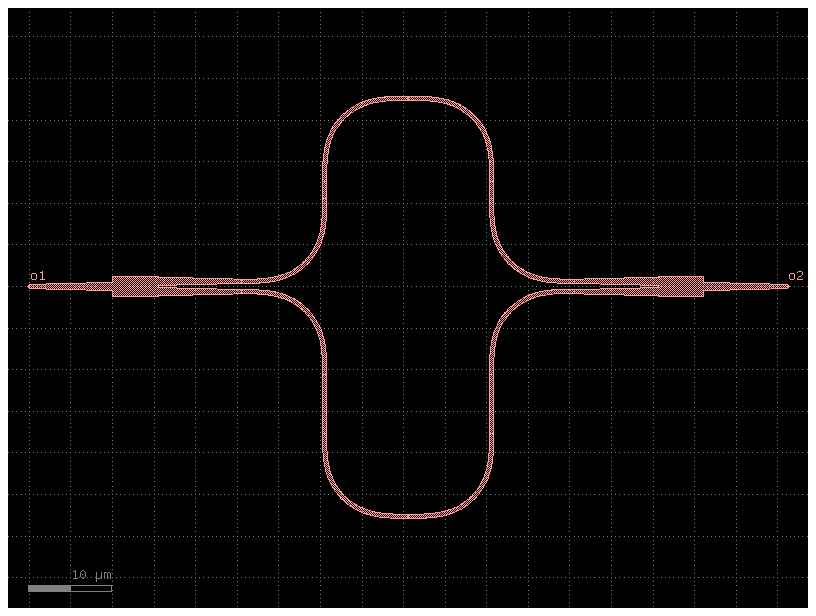

In [56]:
#Create Mach Zender Interferometer (MZI)
mzi_component = gf.components.mzi()

#Display MZI

#Show ports
mzi_component.draw_ports()
mzi_component.plot()

In [57]:
#Load MZI component into simulation manager
simulation_manager.load_component(mzi_component, "mzi")

#Display optical ports associated with MZI
simulation_manager.display_current_ports()

#Display component parameters of MZI
simulation_manager.display_component_parameters()

{'mzi': ['o1', 'o2']}
{'mzi': ['delta_length',
         'length_y',
         'length_x',
         'bend',
         'straight',
         'straight_y',
         'straight_x_top',
         'straight_x_bot',
         'splitter',
         'combiner',
         'with_splitter',
         'port_e1_splitter',
         'port_e0_splitter',
         'port_e1_combiner',
         'port_e0_combiner',
         'port1',
         'port2',
         'nbends',
         'cross_section',
         'cross_section_x_top',
         'cross_section_x_bot',
         'mirror_bot',
         'add_optical_ports_arms',
         'min_length',
         'auto_rename_ports']}


### Define and load simulation parameters

The parameters associated with different facets of the simulation are loaded into the simulation manager. When the simulation manager sets up the simulations, it will be using its loaded parameters.

In [58]:
#OPTICAL PARAMETERS (in um)
#_________________________

#Thickness of waveguide
wg_height = 0.22

#Center wavelength
center_wavelength = 1.55

#Central frequency
center_frequency = td.C_0 / center_wavelength

#Wvelength range
wavelength_range = np.linspace(1.5, 1.6, 1001)

#Frequency range
frequency_range = td.C_0 / wavelength_range
fwidth = 0.5 * (np.max(frequency_range) - np.min(frequency_range))


#SIMULATION PARAMETERS
#_________________________

#Buffer space to add to simulation size
buffer_x = 4.0
buffer_y = 4.0
buffer_z = 2.0

#Parameters associated with flux monitor
monitor_params = {
    'ports': ['o2'], #Monitor at output port
    'monitor_type': 'flux',
    'freqs': frequency_range
}

#Parameters associated with fundamental TE mode associated with refractive index of silicon at 1.55um
mode_spec_params = {
    'num_modes': 1, #Fundamental TE Mode
    'target_neff': '3.48'
}

#Parameters associated with mode source
mode_params = {
    'center': simulation_manager.get_port_coords(simulation_manager.components[0], 'o1'),
    'source_time': td.GaussianPulse(freq0=center_frequency, fwidth=fwidth),
    "direction": "+"
}

#Parameters associated with simulation structures
structure_params = {
    "reference_plane":"bottom",
    "axis" : 2,
    "slab_bounds":(0, wg_height), #Thickness of waveguide
    "medium_wg" : td.Medium(permittivity=3.48**2), #Permittivity of Si
    "medium_sub" : td.Medium(permittivity=1.45**2), #Permittivity of SiO2 substrate
    "add_substrate" : False
}

#Load all simulation parameters into simulation manager
simulation_manager.monitor_params = monitor_params
simulation_manager.mode_spec_params = mode_spec_params
simulation_manager.mode_params = mode_params
simulation_manager.structure_params = structure_params

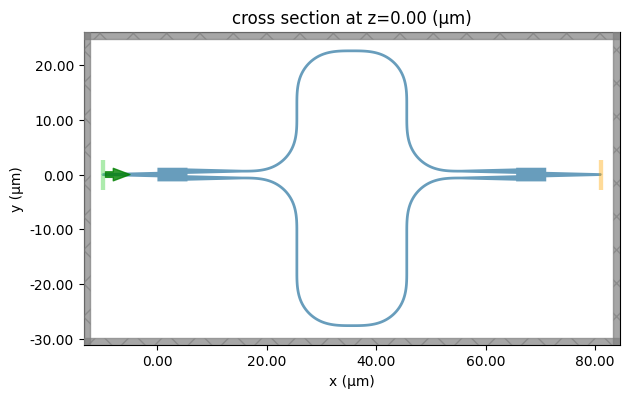

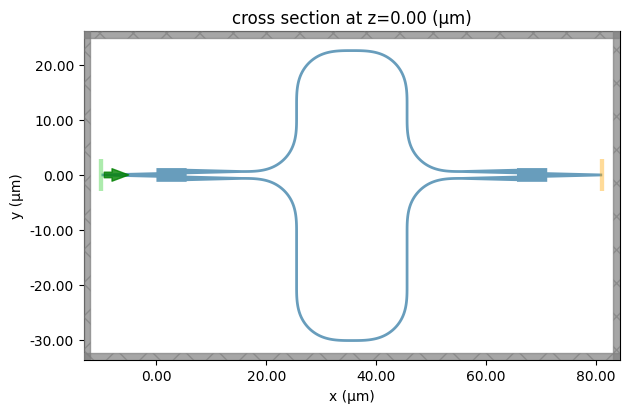

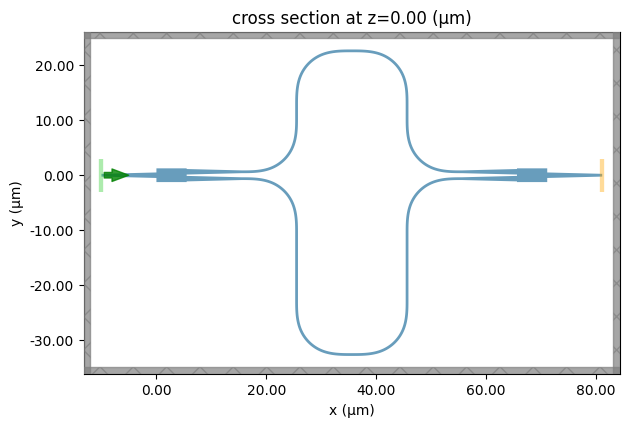

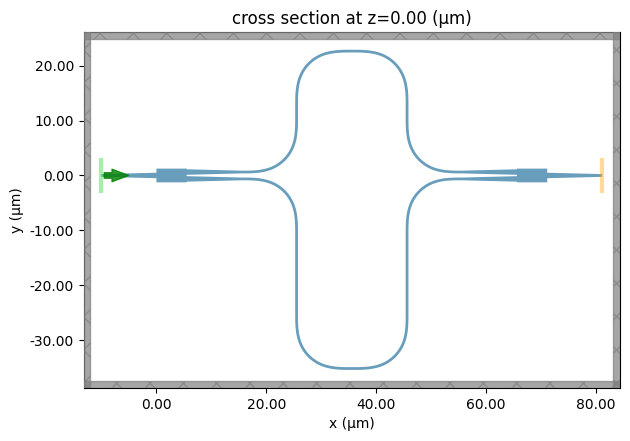

In [59]:
#The delta length parameter is the difference in length between the bottom waveguide arm of the MZI and the top
#in microns
parameter = 'delta_length'

#Create a parameter sweep list over different arm length differences
parameter_list = np.arange(10, 30, 5)

#Use loaded component and simulation parameters to
sims = simulation_manager.create_simulation_sweep(
    parameter=parameter,
    parameter_list=parameter_list,
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15, wavelength=center_wavelength),
    run_time=2e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    sim_buffers=(4, 4, wg_height+4)
)

#Plot simulation cross sections
for sim in sims:
    sim.plot(z=0)


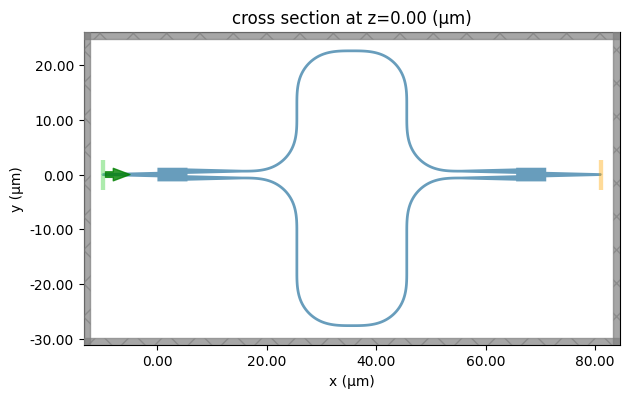

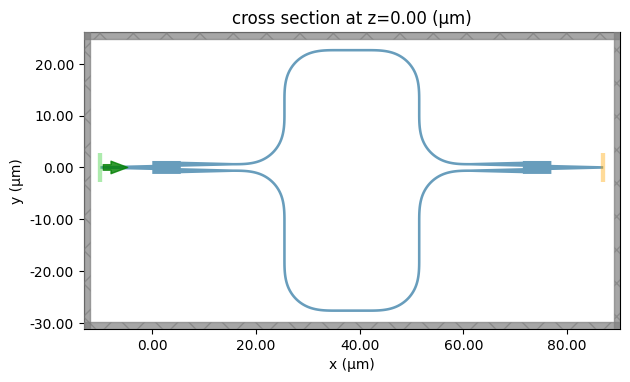

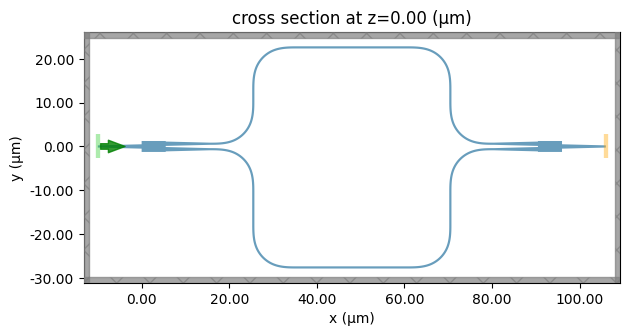

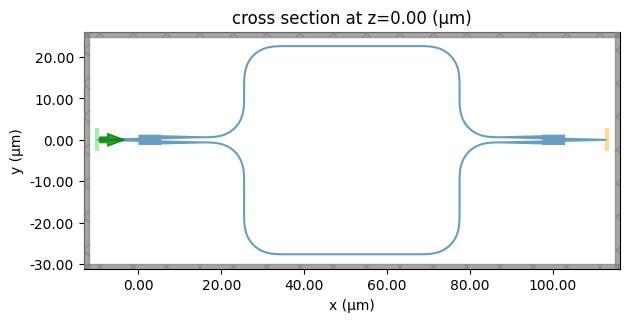

In [60]:
#Length of the horizontal straight region of the MZI waveguide arms
parameter = 'length_x'
parameter_list = [.1, 6, 25, 32]

#Use loaded component and simulation parameters to
sims = simulation_manager.create_simulation_sweep(
    parameter=parameter,
    parameter_list=parameter_list,
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15, wavelength=center_wavelength),
    run_time=2e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    sim_buffers=(4, 4, wg_height+4)
)

#Plot simulation cross sections
for sim in sims:
    sim.plot(z=0)



In [61]:
sims[0].plot_3d()